<a href="https://colab.research.google.com/github/qyasbeb/smartshop-ai/blob/main/Intelligence_artificielle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%            

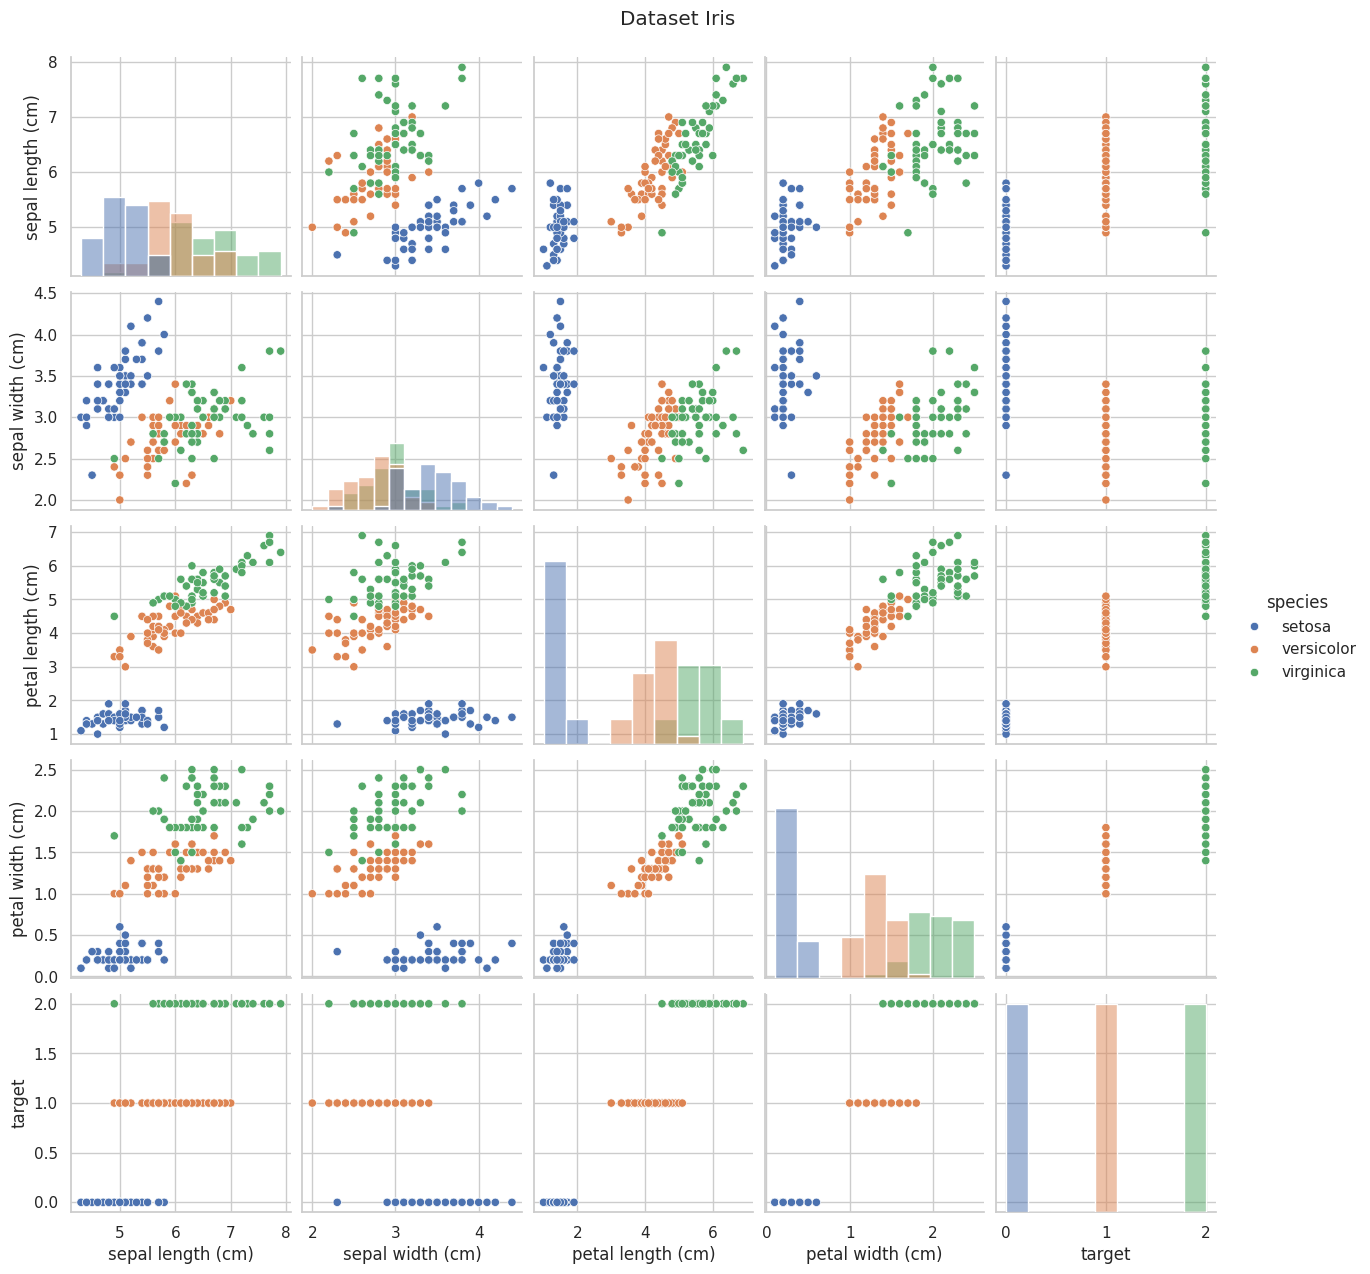

Nombre d'observations par classe :
species
setosa        50
versicolor    50
Name: count, dtype: int64


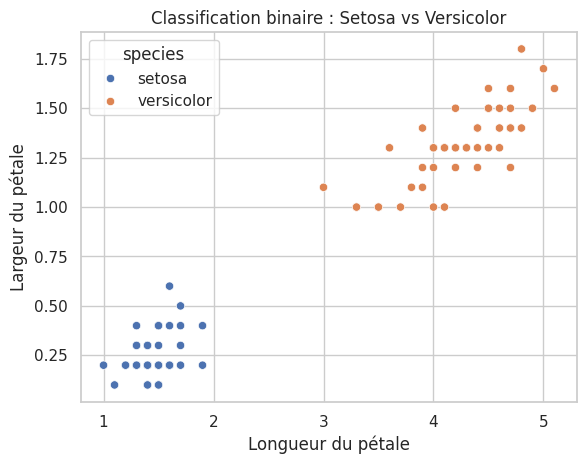

Taille de l'ensemble d'apprentissage : (80, 2)
Taille de l'ensemble de test : (20, 2)
Taille de y_train : (80,)
Taille de y_test : (20,)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Configuration générale de Seaborn
sns.set(style="whitegrid")


# --------------------------------------------------
# Partie 2
# CHARGEMENT DU DATASET IRIS
# --------------------------------------------------

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})


print(df.head())
print(df.describe())
print(df.info())


# --------------------------------------------------
# VISUALISATION DU DATASET
# --------------------------------------------------

sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Dataset Iris",
    y=1.02
)

plt.show()


# --------------------------------------------------
# Partie 3
# Garder uniquement Setosa et Versicolor
# --------------------------------------------------

df_binaire = df[
    df["species"].isin(["setosa", "versicolor"])
].copy()


# 1. Garder uniquement Setosa et Versicolor


# 2. Extraire les deux variables explicatives
# x1 = longueur du pétale
# x2 = largeur du pétale

x1 = df_binaire["petal length (cm)"].values
x2 = df_binaire["petal width (cm)"].values


# 3. Construire le vecteur des labels
# Versicolor = 1
# Setosa = 0

y = df_binaire["target"].values


# 4. Afficher le nombre d'observations de chaque classe

print("Nombre d'observations par classe :")
print(df_binaire["species"].value_counts())


# 5. Représenter les deux classes avec un nuage de points

sns.scatterplot(
    data=df_binaire,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
)

plt.title("Classification binaire : Setosa vs Versicolor")
plt.xlabel("Longueur du pétale")
plt.ylabel("Largeur du pétale")

plt.show()


# --------------------------------------------------
# Partie 4
# Séparation des données
# --------------------------------------------------

X = df_binaire[
    ["petal length (cm)", "petal width (cm)"]
]

y = df_binaire["target"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
llll

print("Taille de l'ensemble d'apprentissage :", X_train.shape)
print("Taille de l'ensemble de test :", X_test.shape)

print("Taille de y_train :", y_train.shape)
print("Taille de y_test :", y_test.shape)

In [ ]:
df.shape

(150, 6)

In [ ]:
# --------------------------------------------------
# Partie 5 : Normalisation des données
# --------------------------------------------------

# Calcul de la moyenne sur les données d'apprentissage
moyenne = X_train.mean()

# Calcul de l'écart-type sur les données d'apprentissage
ecart_type = X_train.std()

# Normalisation de X_train
X_train_norm = (X_train - moyenne) / ecart_type

# Normalisation de X_test avec la moyenne
# et l'écart-type de X_train
X_test_norm = (X_test - moyenne) / ecart_type

print("X_train normalisé :")
print(X_train_norm.head())

print("\nX_test normalisé :")
print(X_test_norm.head())

X_train normalisé :
    petal length (cm)  petal width (cm)
15          -0.951210         -0.694872
52           1.418104          1.277668
60           0.442504          0.381059
66           1.139362          1.277668
68           1.139362          1.277668

X_test normalisé :
    petal length (cm)  petal width (cm)
57           0.303133          0.381059
77           1.487790          1.636311
63           1.278733          1.098346
51           1.139362          1.277668
7           -0.951210         -1.053516


In [ ]:
# --------------------------------------------------
# Partie 6 : Implémentation du perceptron
# --------------------------------------------------

class Perceptron:

    def __init__(self, learning_rate=0.01, n_epochs=100):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = 0

    def fit(self, X, y):

        # Initialisation des poids et du biais
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        # Répéter pendant plusieurs époques
        for epoch in range(self.n_epochs):

            for i in range(len(X)):

                # Calcul de z
                z = np.dot(X.iloc[i], self.weights) + self.bias

                # Fonction seuil
                if z >= 0:
                    prediction = 1
                else:
                    prediction = 0

                # Calcul de l'erreur
                erreur = y.iloc[i] - prediction

                # Mise à jour des poids
                self.weights = self.weights + self.learning_rate * erreur * X.iloc[i]

                # Mise à jour du biais
                self.bias = self.bias + self.learning_rate * erreur

        return self

    def predict(self, X):

        predictions = []

        for i in range(len(X)):

            # Calcul de z
            z = np.dot(X.iloc[i], self.weights) + self.bias

            # Fonction seuil
            if z >= 0:
                prediction = 1
            else:
                prediction = 0

            predictions.append(prediction)

        return np.array(predictions)

In [ ]:
# Création du perceptron

perceptron = Perceptron(
    learning_rate=0.01,
    n_epochs=100
)


# Apprentissage

perceptron.fit(X_train_norm, y_train)


# Prédictions

y_pred = perceptron.predict(X_test_norm)


print("Poids :", perceptron.weights)
print("Biais :", perceptron.bias)
print("Prédictions :", y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Poids : petal length (cm)    0.013937
petal width (cm)     0.010759
dtype: float64
Biais : 0.0
Prédictions : [1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]
Accuracy : 1.0
